# Logistic Regression - simple version
Dataset: `Social_Network_Ads.csv` (Age, EstimatedSalary -> Purchased 0/1)

### 1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

### 2. Load the dataset

In [ ]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


### 3. Independent (x) and dependent (y) features

In [ ]:
x = dataset.iloc[:, :-1]   # Age, EstimatedSalary
y = dataset.iloc[:, -1]    # Purchased

### 4. Train test split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0)

print(x_train.shape, x_test.shape)

(300, 2) (100, 2)


### 5. Feature scaling

In [ ]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### 6. Train the logistic regression model

In [ ]:
classifier = LogisticRegression(random_state=0, max_iter=1000)
classifier.fit(x_train, y_train)

print("Model trained!")
print("Coefficients:", classifier.coef_)
print("Intercept:", classifier.intercept_)

Model trained!
Coefficients: [[2.07665837 1.11008221]]
Intercept: [-0.95217247]


### 7. Prediction

In [ ]:
y_pred = classifier.predict(x_test)
y_proba = classifier.predict_proba(x_test)[:, 1]

print("Predictions (first 20):")
print(y_pred[:20])

Predictions (first 20):
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0]


### 8. Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()
print("TP :", tp)
print("TN :", tn)
print("FP :", fp)
print("FN :", fn)

[[65  3]
 [ 8 24]]
TP : 24
TN : 65
FP : 3
FN : 8


### 9. Plot the confusion matrix

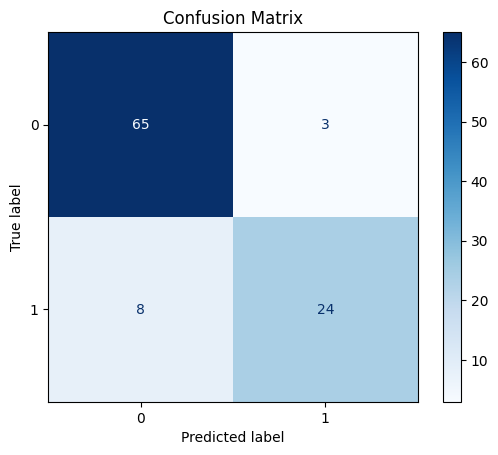

In [ ]:
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### 10. Accuracy

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("Accuracy :", round(acc, 3))
print("Precision:", round(prec, 3))
print("Recall   :", round(rec, 3))

Accuracy : 0.89
Precision: 0.889
Recall   : 0.75


### 11. Threshold sweep - how cutoff affects the metrics

In [ ]:
results = []
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()

    results.append({
        "Threshold": threshold,
        "TP": tp_t,
        "TN": tn_t,
        "FP": fp_t,
        "FN": fn_t,
        "Accuracy": round(accuracy_score(y_test, y_pred_t), 3),
        "Precision": round(precision_score(y_test, y_pred_t, zero_division=0), 3),
        "Recall": round(recall_score(y_test, y_pred_t), 3)
    })

pd.DataFrame(results)

,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall
0,0.3,29,58,10,3,0.87,0.744,0.906
1,0.4,27,61,7,5,0.88,0.794,0.844
2,0.5,24,65,3,8,0.89,0.889,0.750
3,0.6,21,67,1,11,0.88,0.955,0.656
4,0.7,21,67,1,11,0.88,0.955,0.656


### 12. Plot: Precision vs Recall across thresholds

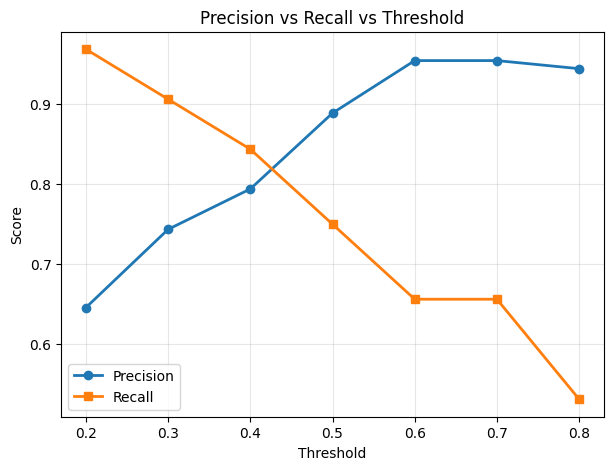

In [ ]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
precisions = []
recalls = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t, zero_division=0))

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions, marker="o", label="Precision", linewidth=2)
plt.plot(thresholds, recalls, marker="s", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 13. GridSearchCV - tune the C parameter

`C` is the inverse of regularisation strength. Smaller C = more regularisation (prevent overfitting).
We'll try C values [0.01, 0.1, 1, 10, 100] with lbfgs solver and l2 penalty.

In [65]:
from sklearn.model_selection import GridSearchCV

c_values = [0.01, 0.1, 1, 10, 100]

param_grid = {
    "C": c_values,
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best C value:", grid.best_params_["C"])
print("Best CV accuracy:", round(grid.best_score_, 4))
print()
print("All results:")
results_df = pd.DataFrame(grid.cv_results_)
print(results_df[["param_C", "mean_test_score", "std_test_score"]].sort_values("param_C"))

Best C value: 1
Best CV accuracy: 0.83

All results:
   param_C  mean_test_score  std_test_score
0     0.01         0.743333        0.024944
1     0.10         0.816667        0.069121
2     1.00         0.830000        0.078457
3    10.00         0.823333        0.084722
4   100.00         0.823333        0.084722


C:\Users\2462443\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### 14. Compare: weak model vs GridSearchCV best model

Both are plain `LogisticRegression` - the only difference is the `C` value.

- **Weak model**: `C=0.01` (very strong regularisation -> underfits, coefficients pushed close to 0)
- **Best model**: whatever `C` GridSearchCV picked as the top performer

This is the same comparison you'd see if you picked a bad hyperparameter by hand vs
letting GridSearchCV search for you.

In [69]:
from sklearn.metrics import roc_auc_score

# weak model: heavy regularisation on purpose (C=0.01)
weak_model = LogisticRegression(C=0.01, random_state=0, max_iter=1000)
weak_model.fit(x_train, y_train)

best_model = grid.best_estimator_   # from GridSearchCV

y_pred_weak = weak_model.predict(x_test)
y_pred_best = best_model.predict(x_test)

y_proba_weak = weak_model.predict_proba(x_test)[:, 1]
y_proba_best = best_model.predict_proba(x_test)[:, 1]

print("WEAK MODEL (C=0.01, too much regularisation):")
print("  Coefficients:", weak_model.coef_)
print("  Accuracy:", round(accuracy_score(y_test, y_pred_weak), 4))
print("  Precision:", round(precision_score(y_test, y_pred_weak), 4))
print("  Recall:", round(recall_score(y_test, y_pred_weak), 4))
print("  AUC:", round(roc_auc_score(y_test, y_proba_weak), 4))

print()
print("BEST TUNED MODEL (C={})".format(grid.best_params_["C"]) + ":")
print("  Coefficients:", best_model.coef_)
print("  Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("  Precision:", round(precision_score(y_test, y_pred_best), 4))
print("  Recall:", round(recall_score(y_test, y_pred_best), 4))
print("  AUC:", round(roc_auc_score(y_test, y_proba_best), 4))

WEAK MODEL (C=0.01, too much regularisation):
  Coefficients: [[0.50707141 0.28323732]]
  Accuracy: 0.84
  Precision: 0.9444
  Recall: 0.5312
  AUC: 0.9536

BEST TUNED MODEL (C=1):
  Coefficients: [[2.07665837 1.11008221]]
  Accuracy: 0.89
  Precision: 0.8889
  Recall: 0.75
  AUC: 0.954


### 15. Confusion matrices side by side

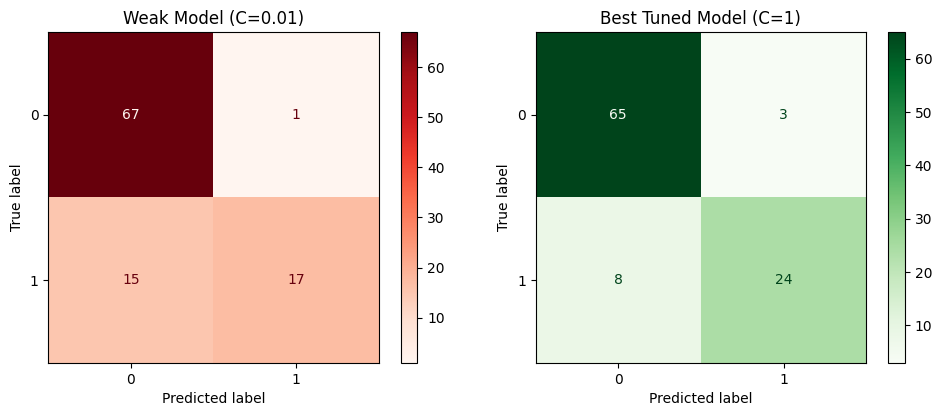

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cm_weak = confusion_matrix(y_test, y_pred_weak)
cm_best = confusion_matrix(y_test, y_pred_best)

ConfusionMatrixDisplay(cm_weak, display_labels=[0, 1]).plot(ax=ax[0], cmap="Reds")
ax[0].set_title("Weak Model (C=0.01)")

ConfusionMatrixDisplay(cm_best, display_labels=[0, 1]).plot(ax=ax[1], cmap="Greens")
ax[1].set_title(f"Best Tuned Model (C={grid.best_params_['C']})")

plt.tight_layout()
plt.show()

### 16. Bar chart - metrics comparison

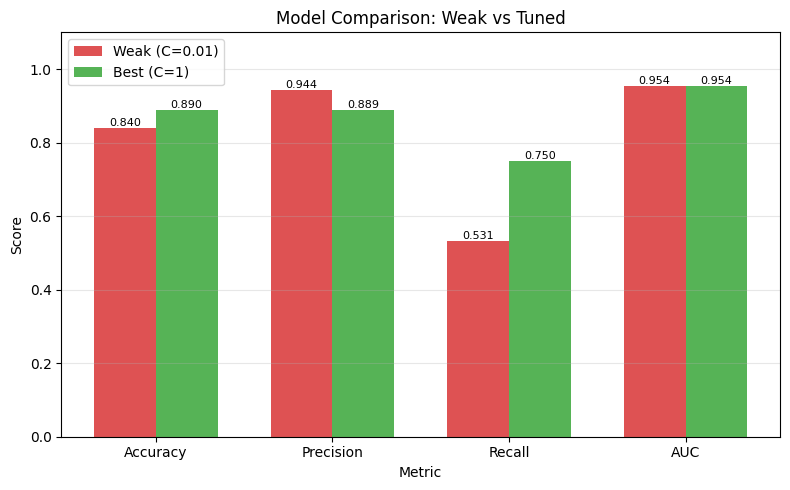

In [71]:
metrics = ["Accuracy", "Precision", "Recall", "AUC"]
weak_scores = [
    accuracy_score(y_test, y_pred_weak),
    precision_score(y_test, y_pred_weak),
    recall_score(y_test, y_pred_weak),
    roc_auc_score(y_test, y_proba_weak)
]
best_scores = [
    accuracy_score(y_test, y_pred_best),
    precision_score(y_test, y_pred_best),
    recall_score(y_test, y_pred_best),
    roc_auc_score(y_test, y_proba_best)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, weak_scores, width, label="Weak (C=0.01)", alpha=0.8, color="tab:red")
bars2 = plt.bar(x + width/2, best_scores, width, label=f"Best (C={grid.best_params_['C']})", alpha=0.8, color="tab:green")

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Model Comparison: Weak vs Tuned")
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3, axis="y")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()